# SROIE Dataset Initial Exploration

This notebook loads the local SROIE dataset through `src.data.sroie` and performs initial validation and exploratory analysis. The raw dataset must be available at `data/raw/SROIE/` or supplied through `DATASET_ROOT`.

In [19]:
from collections import Counter
from pathlib import Path
import importlib
import re
import sys

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import sroie

importlib.reload(sroie)
SROIEValidationError = sroie.SROIEValidationError
load_sroie_dataset = sroie.load_sroie_dataset

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "0325updated.task2train(626p)-20260928T174749Z-1-001"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

WINDOWS_DUPLICATE_SUFFIX = re.compile(r"^(?P<base>.+?)(?:\(\d+\))?$")


def canonical_receipt_id(path: Path) -> str:
    match = WINDOWS_DUPLICATE_SUFFIX.fullmatch(path.stem)
    return match.group("base") if match else path.stem


sns.set_theme(style="whitegrid")

In [20]:
raw_jpg_paths = sorted(
    path for path in DATASET_ROOT.rglob("*") if path.is_file() and path.suffix.lower() == ".jpg"
)
raw_txt_paths = sorted(
    path for path in DATASET_ROOT.rglob("*") if path.is_file() and path.suffix.lower() == ".txt"
)
canonical_jpg_ids = {canonical_receipt_id(path) for path in raw_jpg_paths}
canonical_txt_ids = {canonical_receipt_id(path) for path in raw_txt_paths}
canonical_ids = canonical_jpg_ids | canonical_txt_ids

try:
    dataset = load_sroie_dataset(DATASET_ROOT)
    validation_issues = []
except SROIEValidationError as error:
    validation_issues = list(error.issues)
    dataset = load_sroie_dataset(DATASET_ROOT, strict=False)

invalid_canonical_ids = {
    issue.image_id for issue in validation_issues if issue.image_id is not None
}
print(f"Raw JPG files: {len(raw_jpg_paths)}")
print(f"Raw TXT files: {len(raw_txt_paths)}")
print(f"Canonical receipt IDs: {len(canonical_ids)}")
print(f"Canonical JPG duplicate copies: {len(raw_jpg_paths) - len(canonical_jpg_ids)}")
print(f"Canonical TXT duplicate copies: {len(raw_txt_paths) - len(canonical_txt_ids)}")
print(f"Valid canonical samples: {len(dataset)}")
print(f"Invalid canonical samples: {len(invalid_canonical_ids)}")
print(f"Validation issues: {len(validation_issues)}")
print("Issue counts:")
print(pd.Series(Counter(issue.kind for issue in validation_issues), name="count"))
dataset.head()

Raw JPG files: 735
Raw TXT files: 876
Canonical receipt IDs: 626
Canonical JPG duplicate copies: 109
Canonical TXT duplicate copies: 250
Valid canonical samples: 624
Invalid canonical samples: 2
Validation issues: 2
Issue counts:
empty annotation values    1
missing required fields    1
Name: count, dtype: int64


,image_id,image_path,annotation_path,company,date,address,total,duplicate_image_count,duplicate_annotation_count
0,X00016469612,c:\Users\chech\Documents\AI-Document-Intellige...,c:\Users\chech\Documents\AI-Document-Intellige...,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",9.00,1,1
1,X00016469619,c:\Users\chech\Documents\AI-Document-Intellige...,c:\Users\chech\Documents\AI-Document-Intellige...,INDAH GIFT & HOME DECO,19/10/2018,"27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...",60.30,1,1
2,X00016469620,c:\Users\chech\Documents\AI-Document-Intellige...,c:\Users\chech\Documents\AI-Document-Intellige...,MR D.I.Y. (JOHOR) SDN BHD,12-01-19,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",33.90,1,1
3,X00016469622,c:\Users\chech\Documents\AI-Document-Intellige...,c:\Users\chech\Documents\AI-Document-Intellige...,YONGFATT ENTERPRISE,25/12/2018,NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU,80.90,1,1
4,X00016469623,c:\Users\chech\Documents\AI-Document-Intellige...,c:\Users\chech\Documents\AI-Document-Intellige...,MR D.I.Y. (M) SDN BHD,18-11-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",30.90,1,1


In [21]:
def image_dimensions(image_path: str) -> tuple[int | None, int | None]:
    image = cv2.imread(image_path)
    if image is None:
        return None, None
    height, width = image.shape[:2]
    return width, height

if not dataset.empty:
    dimensions = dataset["image_path"].map(image_dimensions)
    dataset[["width", "height"]] = pd.DataFrame(dimensions.tolist(), index=dataset.index)
    dataset["aspect_ratio"] = dataset["width"] / dataset["height"]
else:
    dataset["width"] = pd.Series(dtype="float64")
    dataset["height"] = pd.Series(dtype="float64")
    dataset["aspect_ratio"] = pd.Series(dtype="float64")

dataset[["width", "height", "aspect_ratio"]].describe()

,width,height,aspect_ratio
count,624.000000,624.000000,624.000000
mean,1327.016026,2357.423077,0.514072
std,1415.845832,1843.925683,0.119655
min,436.000000,605.000000,0.263498
25%,623.000000,1394.750000,0.423521
50%,812.000000,1682.500000,0.501384
75%,935.000000,2137.000000,0.580664
max,4961.000000,7016.000000,0.971354


In [22]:
text_fields = ["company", "date", "address", "total"]
text_lengths = dataset[text_fields].apply(lambda column: column.str.len())
text_lengths.describe().T.rename(columns={"count": "samples"})

,samples,mean,std,min,25%,50%,75%,max
company,624.0,24.850962,7.331099,7.0,19.0,24.0,30.0,49.0
date,624.0,9.592949,0.962048,8.0,9.0,10.0,10.0,12.0
address,624.0,70.831731,17.542854,21.0,56.0,72.0,85.0,135.0
total,624.0,5.121795,0.869257,4.0,5.0,5.0,5.0,8.0


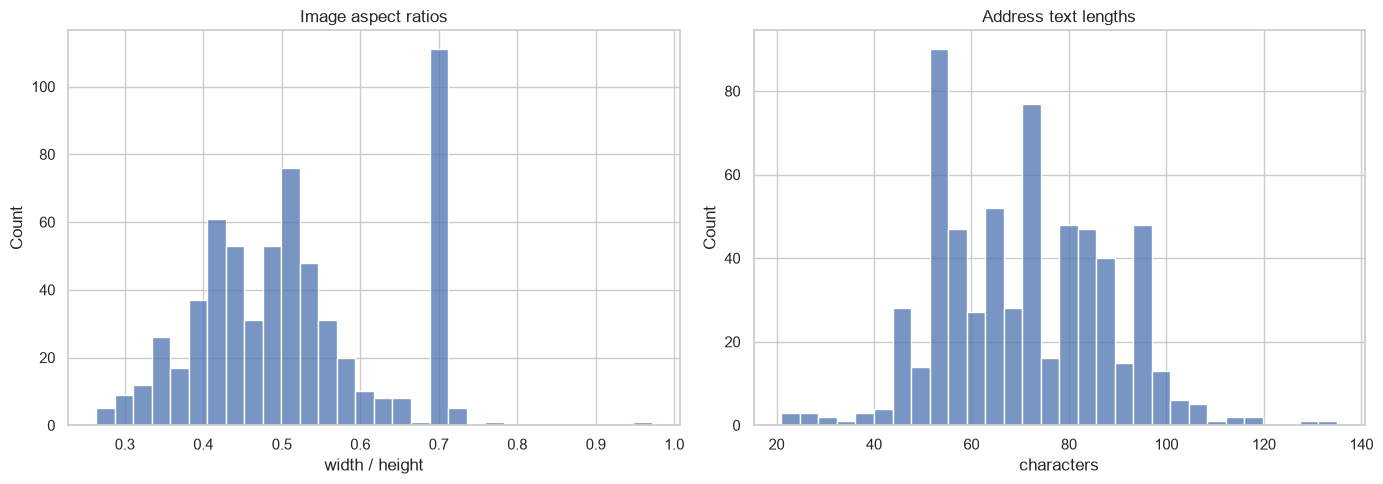

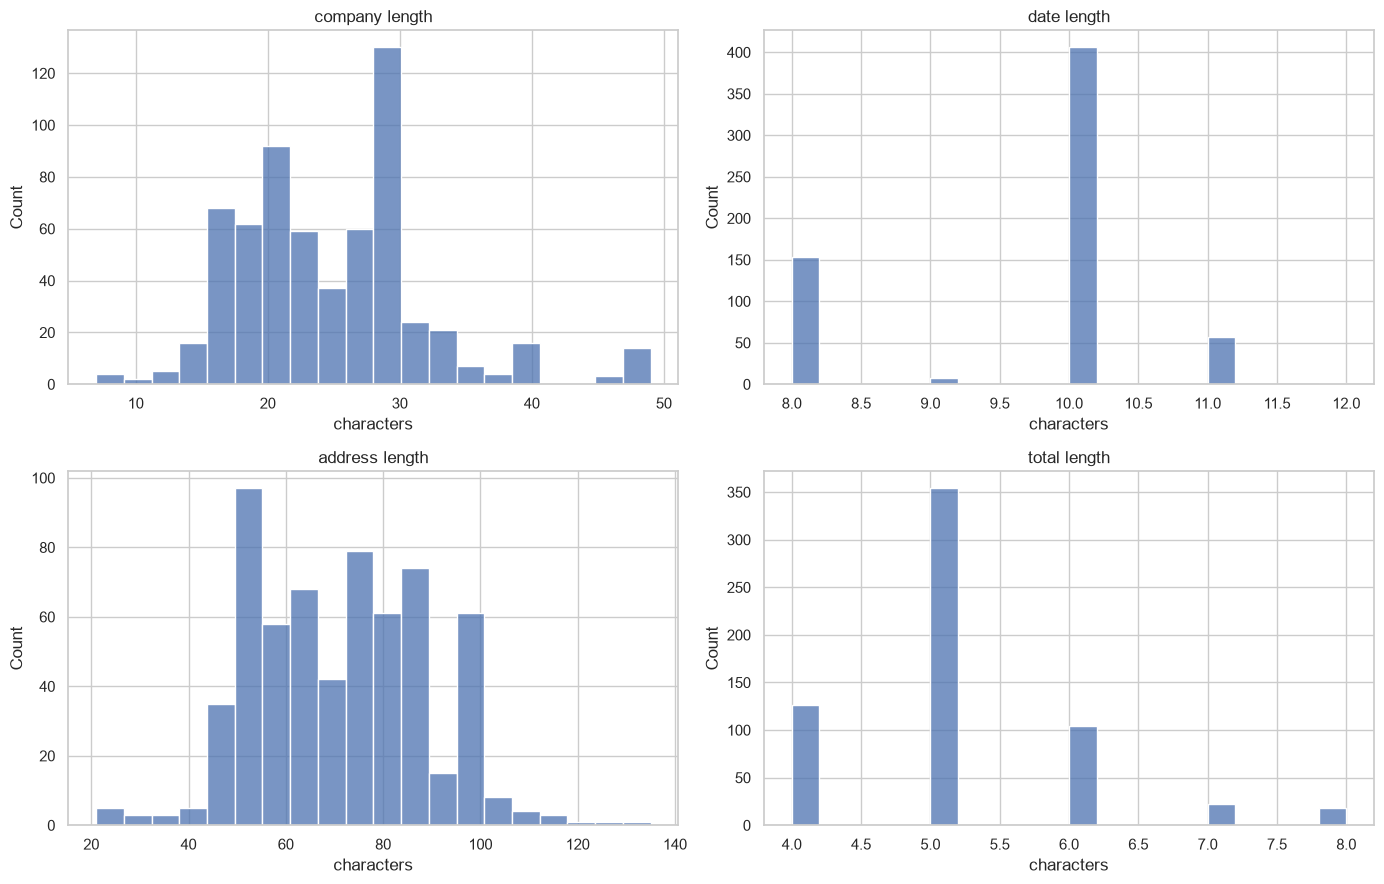

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(dataset["aspect_ratio"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Image aspect ratios")
axes[0].set_xlabel("width / height")

sns.histplot(text_lengths["address"], bins=30, ax=axes[1])
axes[1].set_title("Address text lengths")
axes[1].set_xlabel("characters")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, field in zip(axes.flat, text_fields):
    sns.histplot(text_lengths[field], bins=20, ax=axis)
    axis.set_title(f"{field} length")
    axis.set_xlabel("characters")
plt.tight_layout()
plt.show()

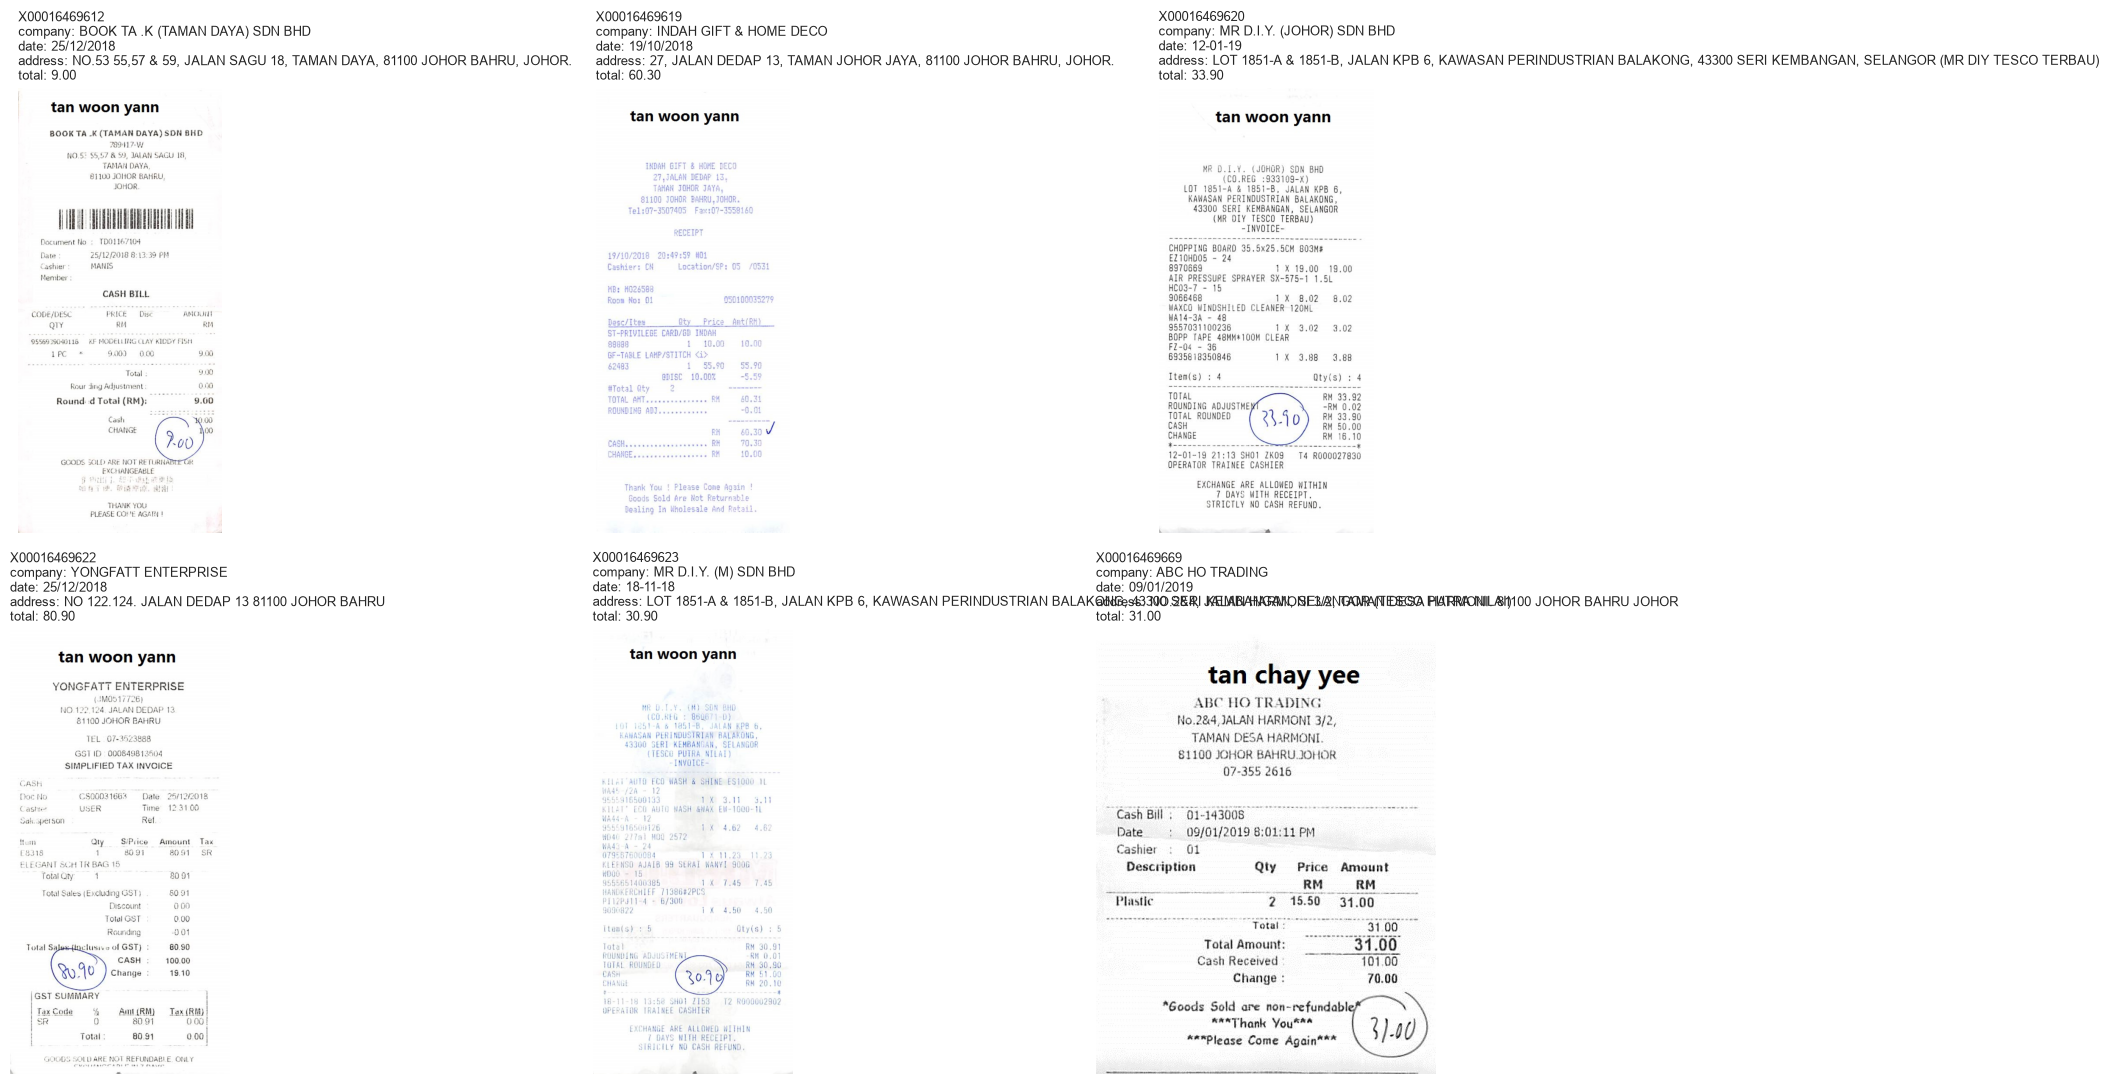

In [24]:
sample_count = min(6, len(dataset))
if sample_count:
    figure, axes = plt.subplots(2, 3, figsize=(18, 11))
    axes = axes.ravel()
    for axis, (_, row) in zip(axes, dataset.head(sample_count).iterrows()):
        image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
        axis.imshow(image)
        axis.axis("off")
        fields = "\n".join(f"{field}: {row[field]}" for field in text_fields)
        axis.set_title(f"{row['image_id']}\n{fields}", fontsize=9, loc="left")
    for axis in axes[sample_count:]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No valid receipt images are available to display.")

In [25]:
metadata_columns = ["image_id", "image_path", *text_fields]
metadata_path = PROCESSED_ROOT / "sroie_metadata.csv"
dataset[metadata_columns].to_csv(metadata_path, index=False)
print(f"Saved lightweight metadata for {len(dataset)} valid samples to {metadata_path}")

Saved lightweight metadata for 624 valid samples to c:\Users\chech\Documents\AI-Document-Intelligence\data\processed\sroie_metadata.csv


In [26]:
import json

from src.ocr import run_batch_ocr

ocr_preview_path = PROCESSED_ROOT / "sroie_ocr_preview.jsonl"
ocr_preview = run_batch_ocr(
    dataset.head(3).to_dict("records"),
    ocr_preview_path,
)
print(f"OCR preview written to {ocr_preview.output_path}")
print(f"Statuses: success={ocr_preview.success}, empty={ocr_preview.empty}, failure={ocr_preview.failure}")

for line in ocr_preview_path.read_text(encoding="utf-8").splitlines():
    result = json.loads(line)
    print(f"\n[{result['image_id']}] {result['status']}")
    print(result["text"][:1000] or result["error_message"] or "No OCR text")

OCR failure for X00016469612: tesseract is not installed or it's not in your PATH. See README file for more information.
OCR failure for X00016469619: tesseract is not installed or it's not in your PATH. See README file for more information.
OCR failure for X00016469620: tesseract is not installed or it's not in your PATH. See README file for more information.


OCR preview written to c:\Users\chech\Documents\AI-Document-Intelligence\data\processed\sroie_ocr_preview.jsonl
Statuses: success=0, empty=0, failure=3

[X00016469612] failure
tesseract is not installed or it's not in your PATH. See README file for more information.

[X00016469619] failure
tesseract is not installed or it's not in your PATH. See README file for more information.

[X00016469620] failure
tesseract is not installed or it's not in your PATH. See README file for more information.
